In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Input, PReLU, BatchNormalization
from tensorflow.keras import initializers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import os
import cv2

In [ ]:
import glob

T = 5
data_dir = 'C:/Users/jamin/turb/temporal/dataset/2Ddecay/CnnNPY'
file_list = sorted(glob.glob(os.path.join(data_dir, 'vorticity*.npy')))

X, Y = [], []

for file_path in file_list:
    data = np.load(file_path)  # shape: (500, 128, 128)

    if data.shape[0] <= T:
        print(f"⚠️ {file_path} 는 timestep이 {T}보다 작습니다!")
        continue

    for t in range(0, data.shape[0] - T):
        x_t = data[t][..., np.newaxis]
        y_t = data[t + T][..., np.newaxis]

        # squeeze로 혹시 남은 차원 제거
        x_t = np.squeeze(x_t)
        y_t = np.squeeze(y_t)

        x_t = x_t[..., np.newaxis]  # 확실히 (128, 128, 1)
        y_t = y_t[..., np.newaxis]

        X.append(x_t)
        Y.append(y_t)

# numpy 배열로 변환 + reshape로 불필요한 차원 제거
X = np.array(X).reshape(-1, 128, 128, 1)
Y = np.array(Y).reshape(-1, 128, 128, 1)

print("✅ 데이터 생성 완료")
print("X shape:", X.shape)
print("Y shape:", Y.shape)


✅ 데이터 생성 완료
X shape: (24750, 128, 128, 1)
Y shape: (24750, 128, 128, 1)


In [ ]:
# input shape 확인용
for i, file in enumerate(file_list[:5]):  # 처음 5개만
    data = np.load(file)
    print(f"{os.path.basename(file)} → shape: {data.shape}")

vorticity10_500_128.npy → shape: (500, 128, 128, 1)
vorticity11_500_128.npy → shape: (500, 128, 128, 1)
vorticity12_500_128.npy → shape: (500, 128, 128, 1)
vorticity13_500_128.npy → shape: (500, 128, 128, 1)
vorticity14_500_128.npy → shape: (500, 128, 128, 1)


In [38]:
# min-max 정규화 (X와 Y 전체 기준)
all_data = np.concatenate([X, Y], axis=0)  # 전체 데이터 합치기
vmin = np.min(all_data)
vmax = np.max(all_data)

print(f"전체 데이터 min: {vmin}, max: {vmax}")

# 정규화 적용
X_norm = (X - vmin) / (vmax - vmin)
Y_norm = (Y - vmin) / (vmax - vmin)

전체 데이터 min: -70.2694, max: 60.6614


In [39]:
# Train/Validation/Test split
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X_norm, Y_norm, test_size=0.2, random_state=42, shuffle=False
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42, shuffle=False
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (19800, 128, 128, 1)
Val shape: (2475, 128, 128, 1)
Test shape: (2475, 128, 128, 1)


In [40]:
# TensorFlow Dataset 변환
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [41]:
# CNN, t => t+T 예측모델
from tensorflow.keras import Model, layers, initializers
import tensorflow as tf

class ConvBlock(tf.keras.layers.Layer):
    def __init__(self, filters, initializer):
        super(ConvBlock, self).__init__()
        self.conv1 = layers.Conv2D(filters, 3, padding='same', kernel_initializer=initializer)
        self.act1 = layers.LeakyReLU(negative_slope=0.2)

        self.conv2 = layers.Conv2D(filters, 3, padding='same', kernel_initializer=initializer)
        self.act2 = layers.LeakyReLU(negative_slope=0.2)

        self.conv3 = layers.Conv2D(filters, 3, padding='same', kernel_initializer=initializer)
        self.act3 = layers.LeakyReLU(negative_slope=0.2)

    def call(self, inputs):
        x = self.act1(self.conv1(inputs))
        x = self.act2(self.conv2(x))
        x = self.act3(self.conv3(x))
        return x

class PredictionCNN(Model):
    def __init__(self):
        super(PredictionCNN, self).__init__()
        self.initializer = tf.keras.initializers.HeNormal(seed=42)

        self.convblk0 = ConvBlock(64, self.initializer)
        self.pool0 = layers.MaxPooling2D()

        self.convblk1 = ConvBlock(128, self.initializer)
        self.pool1 = layers.MaxPooling2D()

        self.convblk2 = ConvBlock(256, self.initializer)

        self.up3 = layers.UpSampling2D()
        self.convblk3 = ConvBlock(128, self.initializer)

        self.up4 = layers.UpSampling2D()
        self.convblk4 = ConvBlock(64, self.initializer)

        self.convblk5 = ConvBlock(32, self.initializer)

        self.output_conv = layers.Conv2D(1, 3, padding='same', kernel_initializer=self.initializer)

    def call(self, inputs, training=False):
        x = self.convblk0(inputs)
        x = self.pool0(x)

        x = self.convblk1(x)
        x = self.pool1(x)

        x = self.convblk2(x)
        x = self.up3(x)

        x = self.convblk3(x)
        x = self.up4(x)

        x = self.convblk4(x)
        x = self.convblk5(x)

        return self.output_conv(x)

def spectral_loss(y_true, y_pred):
    def fft_spectrum(vort):
        # y shape: (batch, H, W, 1)
        vort_complex = tf.cast(vort[..., 0], tf.complex64)
        fft = tf.signal.fft2d(vort_complex)
        ps = tf.math.real(fft * tf.math.conj(fft))  # power spectrum
        return tf.math.log(ps + 1e-8)  # log scaling to balance dynamic range

    spec_true = fft_spectrum(y_true)
    spec_pred = fft_spectrum(y_pred)
    return tf.reduce_mean(tf.square(spec_true - spec_pred))

def custom_loss(y_true, y_pred, lambda_spec=0.1):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    spec = spectral_loss(y_true, y_pred)
    return mse + lambda_spec * spec

In [42]:
# 모델 초기화
model = PredictionCNN()

# 컴파일 (lambda를 써서 lambda_spec 주입)
lambda_spec = 0.1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=lambda y_true, y_pred: custom_loss(y_true, y_pred, lambda_spec),
    metrics=['mae']
)

In [43]:
# 가상의 input을 넣어 output의 크기가 잘 나오는지 확인
# 모델 생성
model = PredictionCNN()

# 샘플 입력으로 한 번 실행
sample_input = tf.random.normal((1, 128, 128, 1))
_ = model(sample_input)  # build 수행

# summary 출력
model.summary()

Model: "prediction_cnn_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_block_30 (ConvBlock)       │ ?                      │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_31 (ConvBlock)       │ ?                      │       369,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_32 (ConvBlock)       │ ?                      │     1,475,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (1, 64, 64, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_33 (ConvBlock)       │ ?                      │       590,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (1, 128, 128, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_34 (ConvBlock)       │ ?                      │       147,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_35 (ConvBlock)       │ ?                      │        36,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_132 (Conv2D)             │ (1, 128, 128, 1)       │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,693,953 (10.28 MB)

 Trainable params: 2,693,953 (10.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import pickle
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 경로 설정
history_dir = "C:/Users/jamin/turb/temporal/dataset/2Ddecay/history_logs"
model_dir = "C:/Users/jamin/turb/temporal/dataset/2Ddecay/model"
os.makedirs(history_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

# 학습 설정
EPOCHS = 500
BATCH_SIZE = 32
lambda_spec = 0.1  # 스펙트럼 손실 비율

# 모델 초기화 및 컴파일
model = PredictionCNN()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=lambda y_true, y_pred: custom_loss(y_true, y_pred, lambda_spec),
    metrics=['mae']
)

# 콜백 설정
checkpoint_path = os.path.join(model_dir, 'best_model.keras')

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True
)

# 모델 학습
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[early_stopping, model_checkpoint]
)

# 히스토리 저장
history_path = os.path.join(history_dir, 'history.pkl')
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)

print(f"모델 및 학습 기록 저장 완료: {checkpoint_path}, {history_path}")

Epoch 1/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 11.2652 - mae: 0.4523

c:\python\Lib\site-packages\keras\src\saving\serialization_lib.py:390: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:     loss=lambda y_true, y_pred: custom_loss(y_true, y_pred, lambda_spec),

  return {key: serialize_keras_object(value) for key, value in obj.items()}


619/619 ━━━━━━━━━━━━━━━━━━━━ 2890s 5s/step - loss: 11.2506 - mae: 0.4519 - val_loss: 0.4358 - val_mae: 0.0561
Epoch 2/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2863s 5s/step - loss: 0.3750 - mae: 0.0679 - val_loss: 0.4069 - val_mae: 0.0406
Epoch 3/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2867s 5s/step - loss: 0.3759 - mae: 0.0390 - val_loss: 0.3556 - val_mae: 0.0516
Epoch 4/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2866s 5s/step - loss: 0.2462 - mae: 0.0302 - val_loss: 0.1936 - val_mae: 0.0190
Epoch 5/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2864s 5s/step - loss: 0.1928 - mae: 0.0202 - val_loss: 0.1868 - val_mae: 0.0152
Epoch 6/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2879s 5s/step - loss: 0.1855 - mae: 0.0180 - val_loss: 0.1859 - val_mae: 0.0179
Epoch 7/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2851s 5s/step - loss: 0.1833 - mae: 0.0168 - val_loss: 0.1798 - val_mae: 0.0150
Epoch 8/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2857s 5s/step - loss: 0.1814 - mae: 0.0166 - val_loss: 0.1801 - val_mae: 0.0151
Epoch 9/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 28

In [ ]:
# 예측 결과 복원 (정규화된 상태라면)
def inverse_normalize(vort, vmin, vmax):
    return vort * (vmax - vmin) + vmin

history_56.pkl not found.
history_67.pkl not found.
history_78.pkl not found.
history_89.pkl not found.


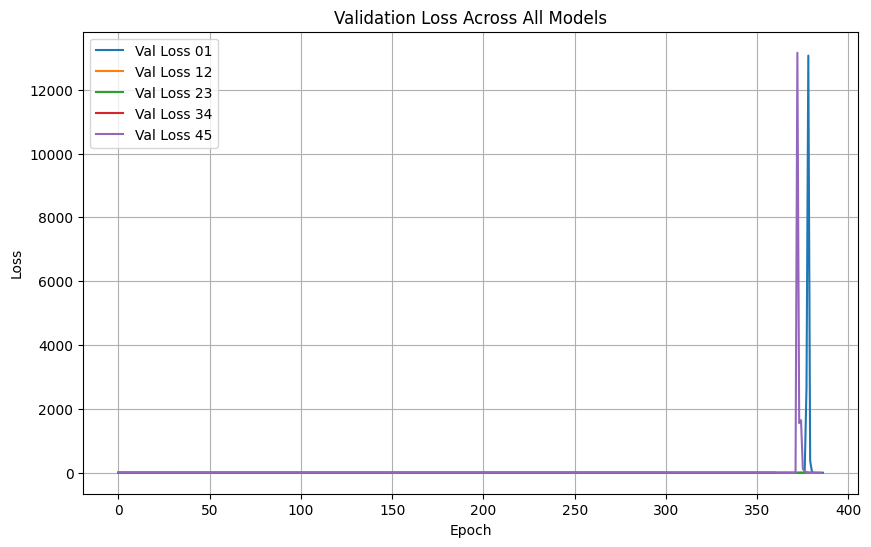

KeyError: 'val_PSNR'

<Figure size 1000x600 with 0 Axes>

In [9]:
# 전체 히스토리 시각화
import pickle

history_folder = "C:/Users/jamin/turb/temporal/dataset/isotropic1024coarse/history_logs"
num_models = 9  # t=0~9 → 0→1, ..., 8→9

# 전체 히스토리를 담을 딕셔너리
all_histories = {}

for t in range(num_models):
    filename = f"history_{t}{t+1}.pkl"
    path = os.path.join(history_folder, filename)

    if os.path.exists(path):
        with open(path, 'rb') as f:
            hist = pickle.load(f)
            all_histories[f"{t}{t+1}"] = hist
    else:
        print(f"{filename} not found.")

# 1. 전체 loss 그래프 비교
plt.figure(figsize=(10, 6))
for key, hist in all_histories.items():
    plt.plot(hist['val_loss'], label=f'Val Loss {key}')
plt.title('Validation Loss Across All Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2. 전체 PSNR 그래프 비교
plt.figure(figsize=(10, 6))
for key, hist in all_histories.items():
    plt.plot(hist['val_PSNR'], label=f'Val PSNR {key}')
plt.title('Validation PSNR Across All Models')
plt.xlabel('Epoch')
plt.ylabel('PSNR')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# val_data에서 하나 선택해 간단히 확인
# 예측 시작할 초기 입력 프레임 (예: val_data[0, 0])
initial_input = val_data[0, 0]  # shape: (128, 128, 3)
current_input = np.expand_dims(initial_input, axis=0)  # shape: (1, 128, 128, 3)

predictions = [current_input[0]]  # 첫 프레임 저장

# 순차적으로 모델 불러와서 예측
for t in range(1):  # 0→1, ..., 8→9
    model_path = f'C:/Users/jamin/turb/temporal/dataset/isotropic1024coarse/model/best_model_{t}{t+1}'
    model = tf.keras.models.load_model(model_path, custom_objects={'custom_loss': custom_loss, 'PSNR': PSNR})

    next_output = model.predict(current_input)
    predictions.append(next_output[0])  # 결과 프레임 저장
    current_input = next_output  # 다음 입력으로 사용

# 역정규화 함수
def inverse_normalize(data, data_min, data_max):
    return data * (data_max - data_min) + data_min

predictions = np.array(predictions)  # shape: (10, 128, 128, 3)
predictions = inverse_normalize(predictions, data_min, data_max) # 역정규화
val_data = inverse_normalize(val_data, data_min, data_max) # 역정규화

ValueError: File format not supported: filepath=C:/Users/jamin/turb/temporal/dataset/isotropic1024coarse/model/best_model_01. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(C:/Users/jamin/turb/temporal/dataset/isotropic1024coarse/model/best_model_01, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).

In [11]:
# plot해 ground truth와 prediction 비교하는 함수
def plot_gt_vs_prediction(gt_seq, pred_seq, t_range=None, cmap='inferno', channel=0):
    """
    gt_seq, pred_seq: (T, H, W, 3)
    t_range: 표시할 시간 인덱스 리스트 (예: [0, 2, 4, 6, 8])
    channel: 시각화할 벡터 성분 (0: u, 1: v, 2: w)
    """
    T = gt_seq.shape[0]
    if t_range is None:
        t_range = list(range(T))  # 모든 시간 프레임

    n = len(t_range)
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))

    for i, t in enumerate(t_range):
        gt_img = gt_seq[t, ..., channel]
        pred_img = pred_seq[t, ..., channel]

        axes[0, i].imshow(gt_img, cmap=cmap)
        axes[0, i].set_title(f'GT t={t}')
        axes[0, i].axis('off')

        axes[1, i].imshow(pred_img, cmap=cmap)
        axes[1, i].set_title(f'Pred t={t}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

TypeError: list indices must be integers or slices, not tuple

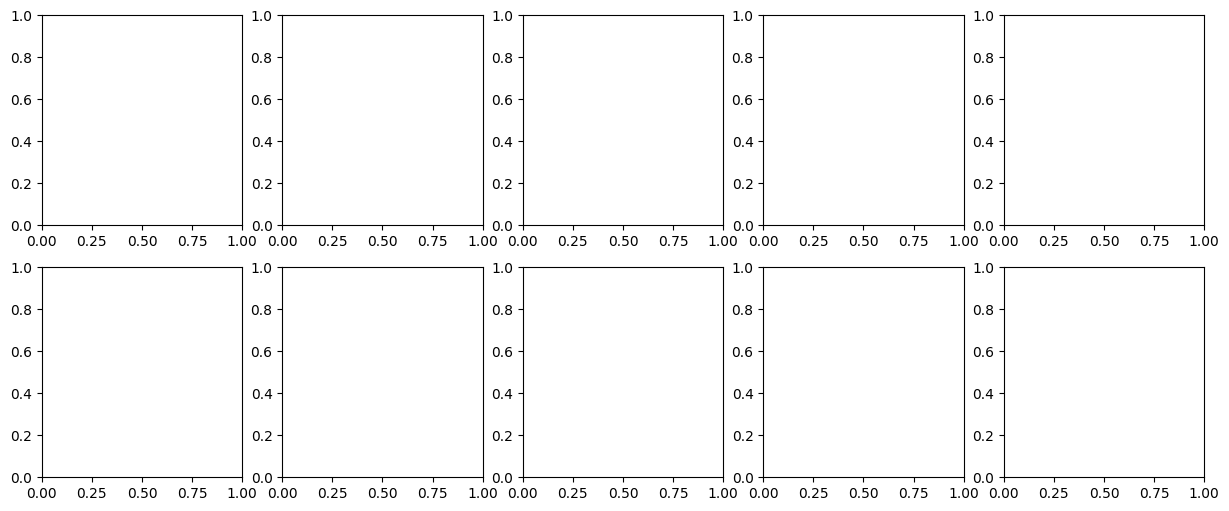

In [12]:
# 시각화 (예: u 성분, 0~9 중 일부만 보기)
ground_truths = val_data[0] # 첫 번째 블록의 전체 시퀀스
plot_gt_vs_prediction(ground_truths, predictions, t_range=[0, 1, 4, 6, 8], channel=0)

In [13]:
# 속도장의 에너지 스펙트럼 비교 함수 (pred vs ground truth)
from numpy.fft import fft2, fftshift
def compute_energy_spectrum_2d(vector_field):
    """
    vector_field: shape (H, W, 3), 3 = (u, v, w)
    return: 1D energy spectrum E(k)
    """
    H, W, _ = vector_field.shape

    # FFT 각 성분
    u_hat = fft2(vector_field[..., 0])
    v_hat = fft2(vector_field[..., 1])
    w_hat = fft2(vector_field[..., 2])

    # Power spectral density
    E_u = np.abs(u_hat) ** 2
    E_v = np.abs(v_hat) ** 2
    E_w = np.abs(w_hat) ** 2

    E_total = E_u + E_v + E_w
    E_total = fftshift(E_total)  # 중심 이동

    # 파수 벡터
    kx = np.fft.fftfreq(W) * W
    ky = np.fft.fftfreq(H) * H
    kx, ky = np.meshgrid(kx, ky)
    k_mag = np.sqrt(kx**2 + ky**2)
    k_mag = fftshift(k_mag)

    # 이산 bin에 따라 평균
    k_max = int(np.max(k_mag))
    E_k = np.zeros(k_max)
    counts = np.zeros(k_max)

    for i in range(H):
        for j in range(W):
            k = int(k_mag[i, j])
            if k < k_max:
                E_k[k] += E_total[i, j]
                counts[k] += 1

    # Normalize by number of modes per bin
    E_k = E_k / (counts + 1e-10)

    return E_k

In [17]:
# 예시: 비교 대상 프레임 (예: t = 9)
t_target = 3
pred_frame = predictions[t_target]      # shape: (128, 128, 3)
gt_frame = val_data[0, t_target]        # shape: (128, 128, 3)

# 계산
Ek_pred = compute_energy_spectrum_2d(pred_frame)
Ek_gt = compute_energy_spectrum_2d(gt_frame)

# 시각화
plt.figure(figsize=(6, 4))
plt.plot(Ek_gt, label='Ground Truth', lw=2)
plt.plot(Ek_pred, label='Prediction', lw=2, linestyle='--')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Wavenumber k')
plt.ylabel('E(k)')
plt.title(f'Energy Spectrum at t={t_target}')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.show()

IndexError: list index out of range

In [15]:
# 전체 프레임의 평균 속도장 에너지 스펙트럼을 구하는 함수
def compute_mean_energy_spectrum(pred_seq, gt_seq):
    """
    pred_seq, gt_seq: shape (T, H, W, 3)
    return: (E_k_pred_mean, E_k_gt_mean)
    """
    T = pred_seq.shape[0]
    spectra_pred = []
    spectra_gt = []

    for t in range(T):
        Ek_pred = compute_energy_spectrum_2d(pred_seq[t])
        Ek_gt = compute_energy_spectrum_2d(gt_seq[t])

        spectra_pred.append(Ek_pred)
        spectra_gt.append(Ek_gt)

    # padding을 고려해 동일 길이로 잘라내기
    min_len = min([len(s) for s in spectra_pred + spectra_gt])
    spectra_pred = np.array([s[:min_len] for s in spectra_pred])
    spectra_gt = np.array([s[:min_len] for s in spectra_gt])

    return spectra_pred.mean(axis=0), spectra_gt.mean(axis=0)

In [16]:
# 사용 예시
gt_seq = val_data[0]         # shape: (10, 128, 128, 3)
pred_seq = predictions       # shape: (10, 128, 128, 3)

Ek_pred_mean, Ek_gt_mean = compute_mean_energy_spectrum(pred_seq, gt_seq)

plt.figure(figsize=(6, 4))
plt.plot(Ek_gt_mean, label='GT Mean Spectrum', lw=2)
plt.plot(Ek_pred_mean, label='Pred Mean Spectrum', lw=2, linestyle='--')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Wavenumber k')
plt.ylabel('E(k)')
plt.title('Mean Energy Spectrum over All Timesteps')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.show()


AttributeError: 'list' object has no attribute 'shape'

In [ ]:
# 2D vorticity 계산 함
def compute_vorticity_2d(velocity_field):
    """
    velocity_field: (H, W, 3) → (u, v, w)
    returns: vorticity ω_z (H, W)
    """
    u = velocity_field[..., 0]
    v = velocity_field[..., 1]

    du_dy = np.gradient(u, axis=0)
    dv_dx = np.gradient(v, axis=1)

    vorticity = dv_dx - du_dy
    return vorticity

# pdf 계산 함수
def compute_pdf(data, bins=100, range=None):
    hist, bin_edges = np.histogram(data.flatten(), bins=bins, density=True, range=range)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    return bin_centers, hist


In [ ]:
# vorticity pdf 비(pred vs ground truth)
# 예시: 마지막 시점 t=9
t_target = 9
vorticity_pred = compute_vorticity_2d(predictions[t_target])
vorticity_gt = compute_vorticity_2d(val_data[0, t_target])

# PDF 계산
bins = 100
v_min = min(vorticity_gt.min(), vorticity_pred.min())
v_max = max(vorticity_gt.max(), vorticity_pred.max())
v_range = (v_min, v_max)

pdf_x_gt, pdf_y_gt = compute_pdf(vorticity_gt, bins=bins, range=v_range)
pdf_x_pred, pdf_y_pred = compute_pdf(vorticity_pred, bins=bins, range=v_range)

# 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(pdf_x_gt, pdf_y_gt, label='GT', lw=2)
plt.plot(pdf_x_pred, pdf_y_pred, label='Prediction', lw=2, linestyle='--')
plt.xlabel('Vorticity ωₓ')
plt.ylabel('Probability Density')
plt.title(f'Vorticity PDF at t={t_target}')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 전체 시간 평균 속도장의 vorticity pdf 비교
# 전체 시간 vorticity pdf 계산 함
def compute_mean_vorticity_pdf(pred_seq, gt_seq, bins=100):
    """
    pred_seq, gt_seq: shape (T, H, W, 3)
    returns: pdf_x (bin center), mean_pdf_pred, mean_pdf_gt
    """
    T = pred_seq.shape[0]

    # 먼저 전체 데이터의 vorticity 값 범위 구하기
    all_vorticities = []
    for t in range(T):
        v_pred = compute_vorticity_2d(pred_seq[t])
        v_gt = compute_vorticity_2d(gt_seq[t])
        all_vorticities.extend([v_pred.flatten(), v_gt.flatten()])

    v_min = min(map(np.min, all_vorticities))
    v_max = max(map(np.max, all_vorticities))
    v_range = (v_min, v_max)

    # 각 프레임의 PDF 계산
    pdfs_pred = []
    pdfs_gt = []

    for t in range(T):
        v_pred = compute_vorticity_2d(pred_seq[t])
        v_gt = compute_vorticity_2d(gt_seq[t])

        x, pdf_pred = compute_pdf(v_pred, bins=bins, range=v_range)
        _, pdf_gt = compute_pdf(v_gt, bins=bins, range=v_range)

        pdfs_pred.append(pdf_pred)
        pdfs_gt.append(pdf_gt)

    # 평균
    mean_pdf_pred = np.mean(pdfs_pred, axis=0)
    mean_pdf_gt = np.mean(pdfs_gt, axis=0)

    return x, mean_pdf_pred, mean_pdf_gt

In [ ]:
# 사용 예시: 전체 시간 평
gt_seq = val_data[0]       # (10, 128, 128, 3)
pred_seq = predictions     # (10, 128, 128, 3)

x_bins, mean_pdf_pred, mean_pdf_gt = compute_mean_vorticity_pdf(pred_seq, gt_seq, bins=100)

# 시각화
plt.figure(figsize=(6, 4))
plt.plot(x_bins, mean_pdf_gt, label='GT Mean PDF', lw=2)
plt.plot(x_bins, mean_pdf_pred, label='Pred Mean PDF', lw=2, linestyle='--')
plt.xlabel('Vorticity ωₓ')
plt.ylabel('Mean Probability Density')
plt.title('Mean Vorticity PDF over Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
================================================================================

In [ ]:
# 미완

In [ ]:
from scipy.stats import pearsonr
from skimage.metrics import structural_similarity as ssim

# 피어슨 상관계수
true_velocity = hr_img_test[:, :, :].flatten()
pred_velocity = predicted_img[:, :, :].flatten()
corr, _ = pearsonr(true_velocity, pred_velocity)
print(f"Pearson Correlation Coefficient: {corr:.4f}")

# SSIM
win_size = 3
ssim_value = ssim(hr_img_test, predicted_img,
                  channel_axis=-1,
                  win_size=win_size,
                  data_range=predicted_img.max() - predicted_img.min())
print(f"SSIM: {ssim_value:.4f}")

In [ ]:
# pred_test = 복원된 고해상도 데이터
pred_test = esrcnn_model.predict(lr_test)

data_list = []

# 안전하게 u, v, w 성분 추출
for i in range(len(pred_test)):
    u, v, w = safe_extract_uv_w(pred_test[i])
    data_list.append((u, v, w))

# 연속 방정식의 오차 계산 함수
def compute_continuity_error(u, v, w, dx, dy, dz):
    du_dx = np.gradient(u, dx, axis=0)
    dv_dy = 0  # y 방향은 2D 평면이므로 무시
    dw_dz = np.gradient(w, dz, axis=1)
    continuity_error = du_dx + dv_dy + dw_dz
    error_magnitude = np.abs(continuity_error)
    error_avg = np.mean(error_magnitude)
    return error_avg

# 평균 오차 계산 함수
def compute_average_continuity_error(data_list, dx, dy, dz):
    error_list = []
    for u, v, w in data_list:
        error_avg = compute_continuity_error(u, v, w, dx, dy, dz)
        error_list.append(error_avg)
    total_error_avg = np.mean(error_list)
    return total_error_avg, error_list

# 격자 간격
dx = 1.0 / 128
dy = 1.0  # 의미 없음
dz = 1.0 / 128

# 계산 실행
total_error_avg, error_list = compute_average_continuity_error(data_list, dx, dy, dz)

print("Total Average Continuity Error:", total_error_avg)
